<a href="https://colab.research.google.com/github/OJB-Quantum/Spintronics-Generative-Layouts/blob/main/Micron_ST_FMR_Devices_Test_Array_with_Labels_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# This code cell installs the required packages needed for the layout generation.

!python -m pip install -q uv
!uv pip install --system -q phidl gdstk ezdxf gdspy || python -m pip install -q phidl gdstk ezdxf gdspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.3/26.3 MB 57.6 MB/s eta 0:00:00


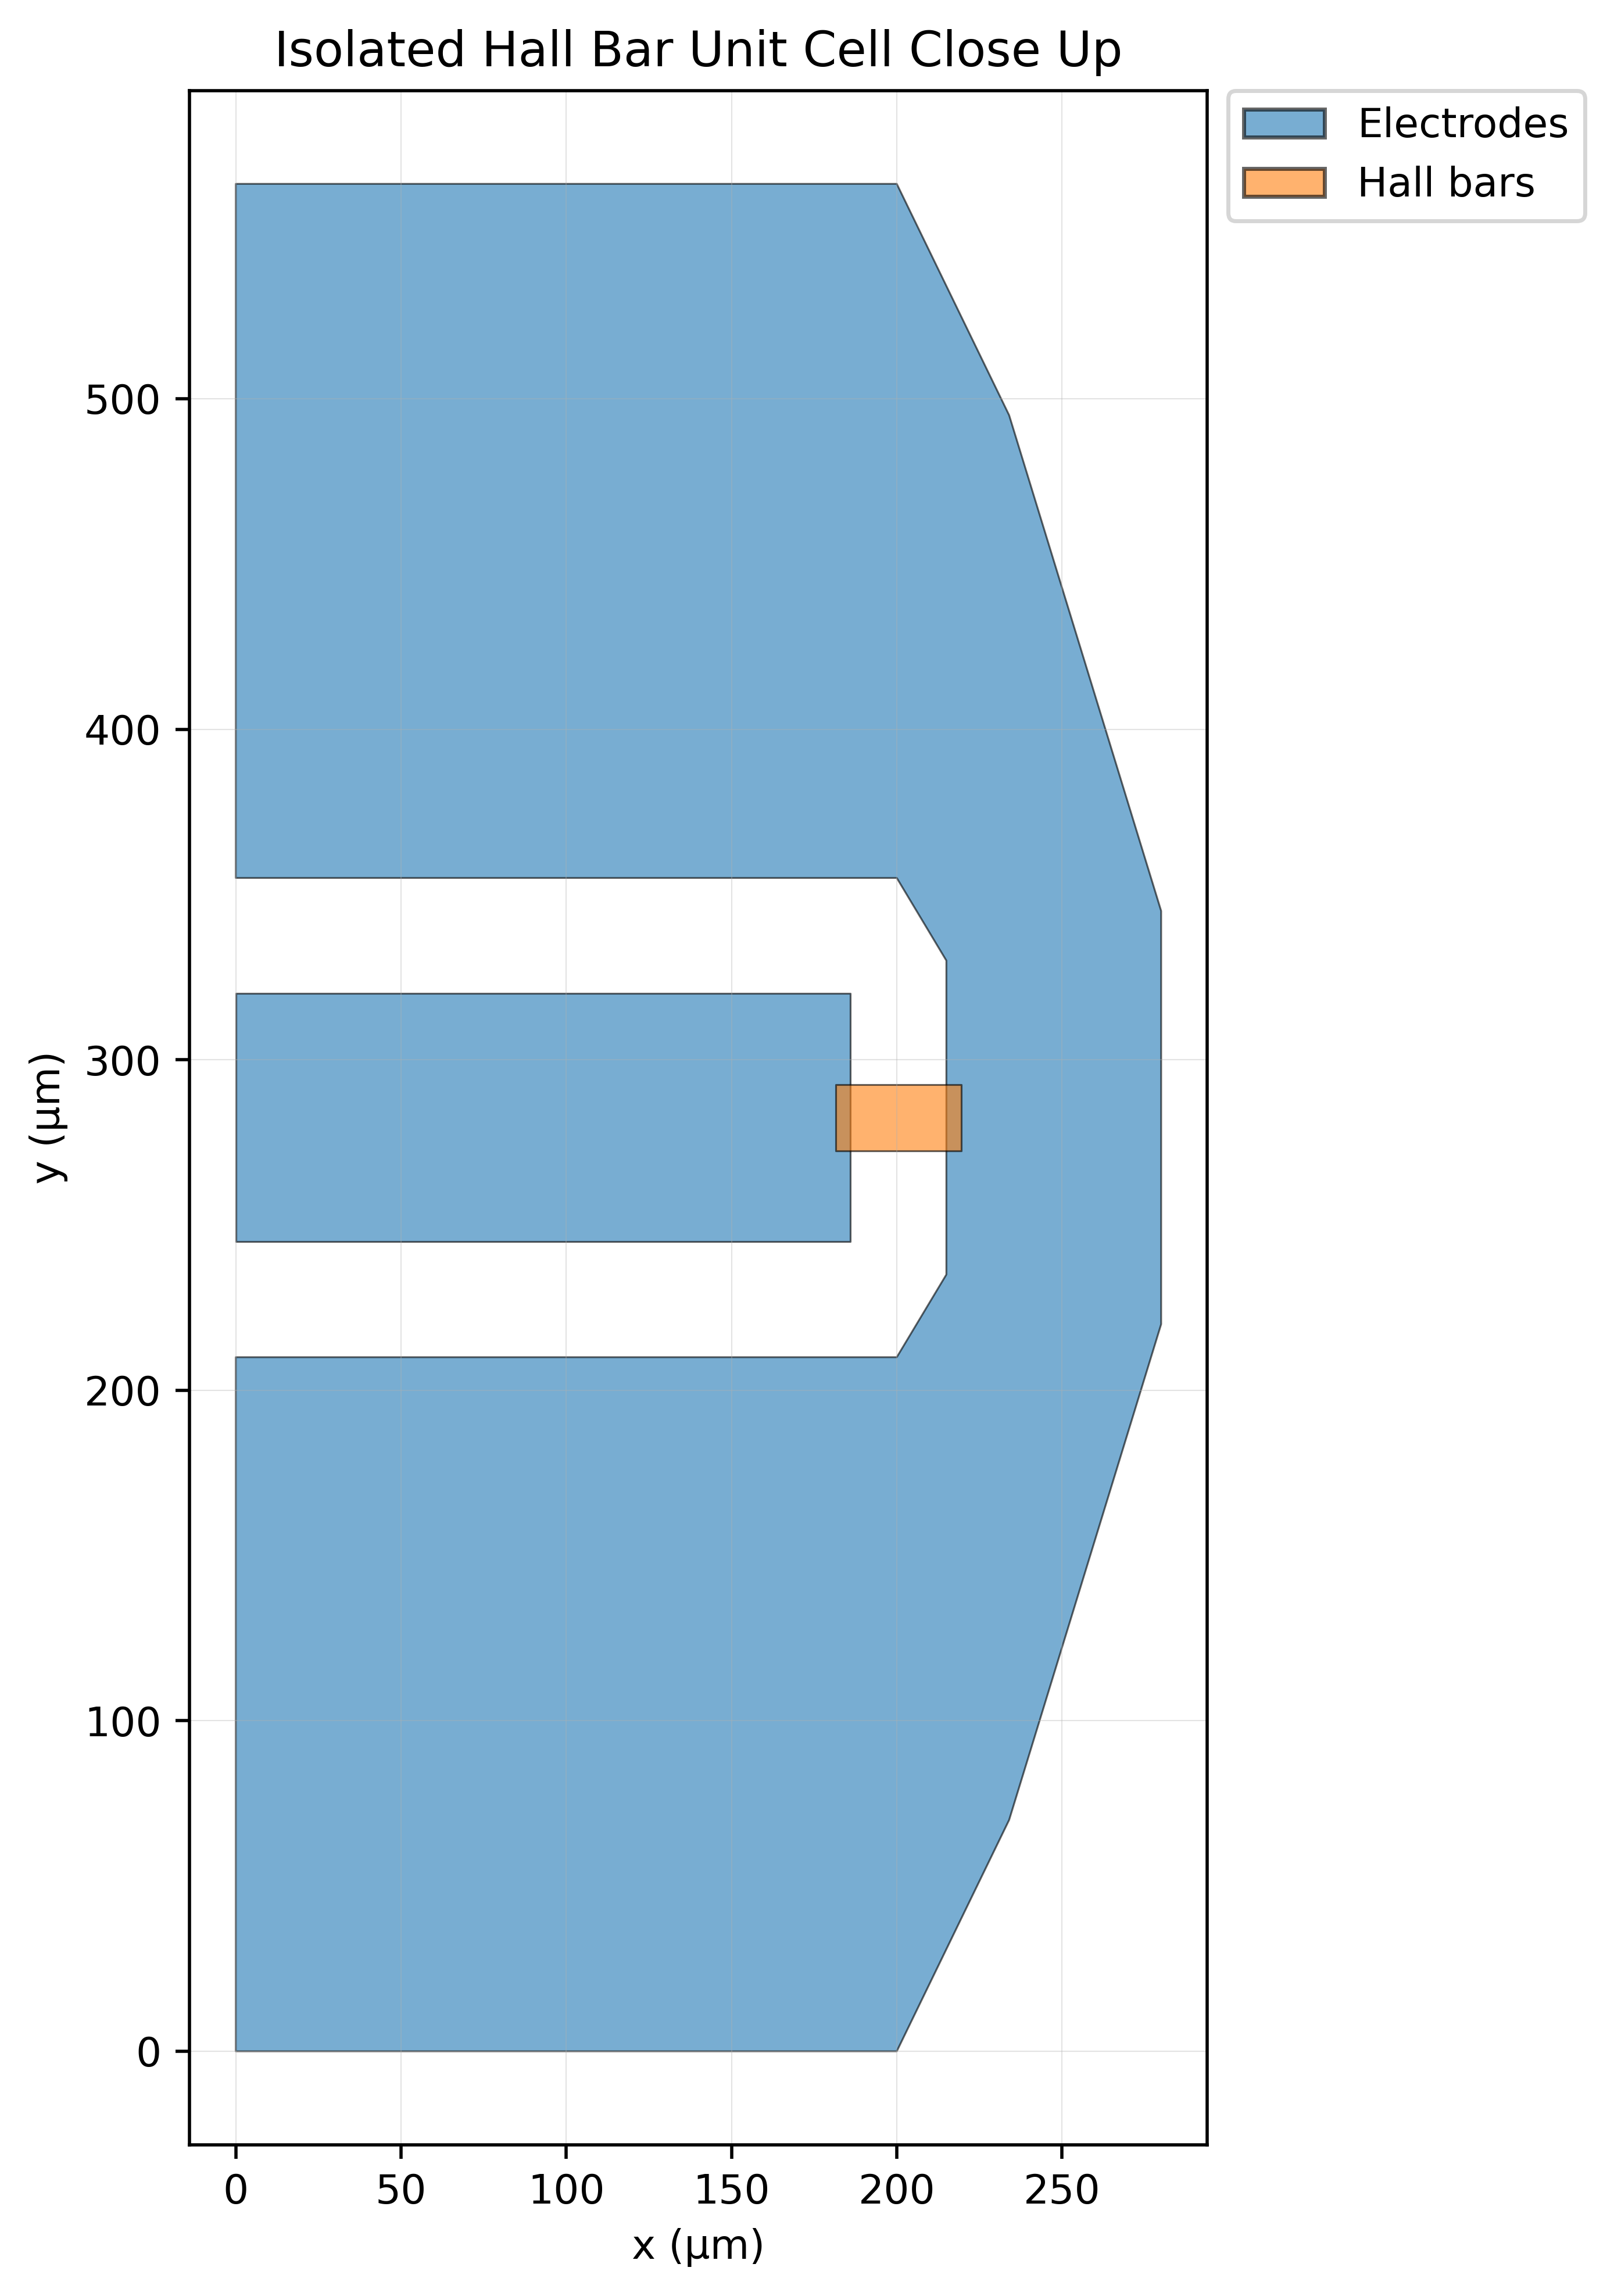

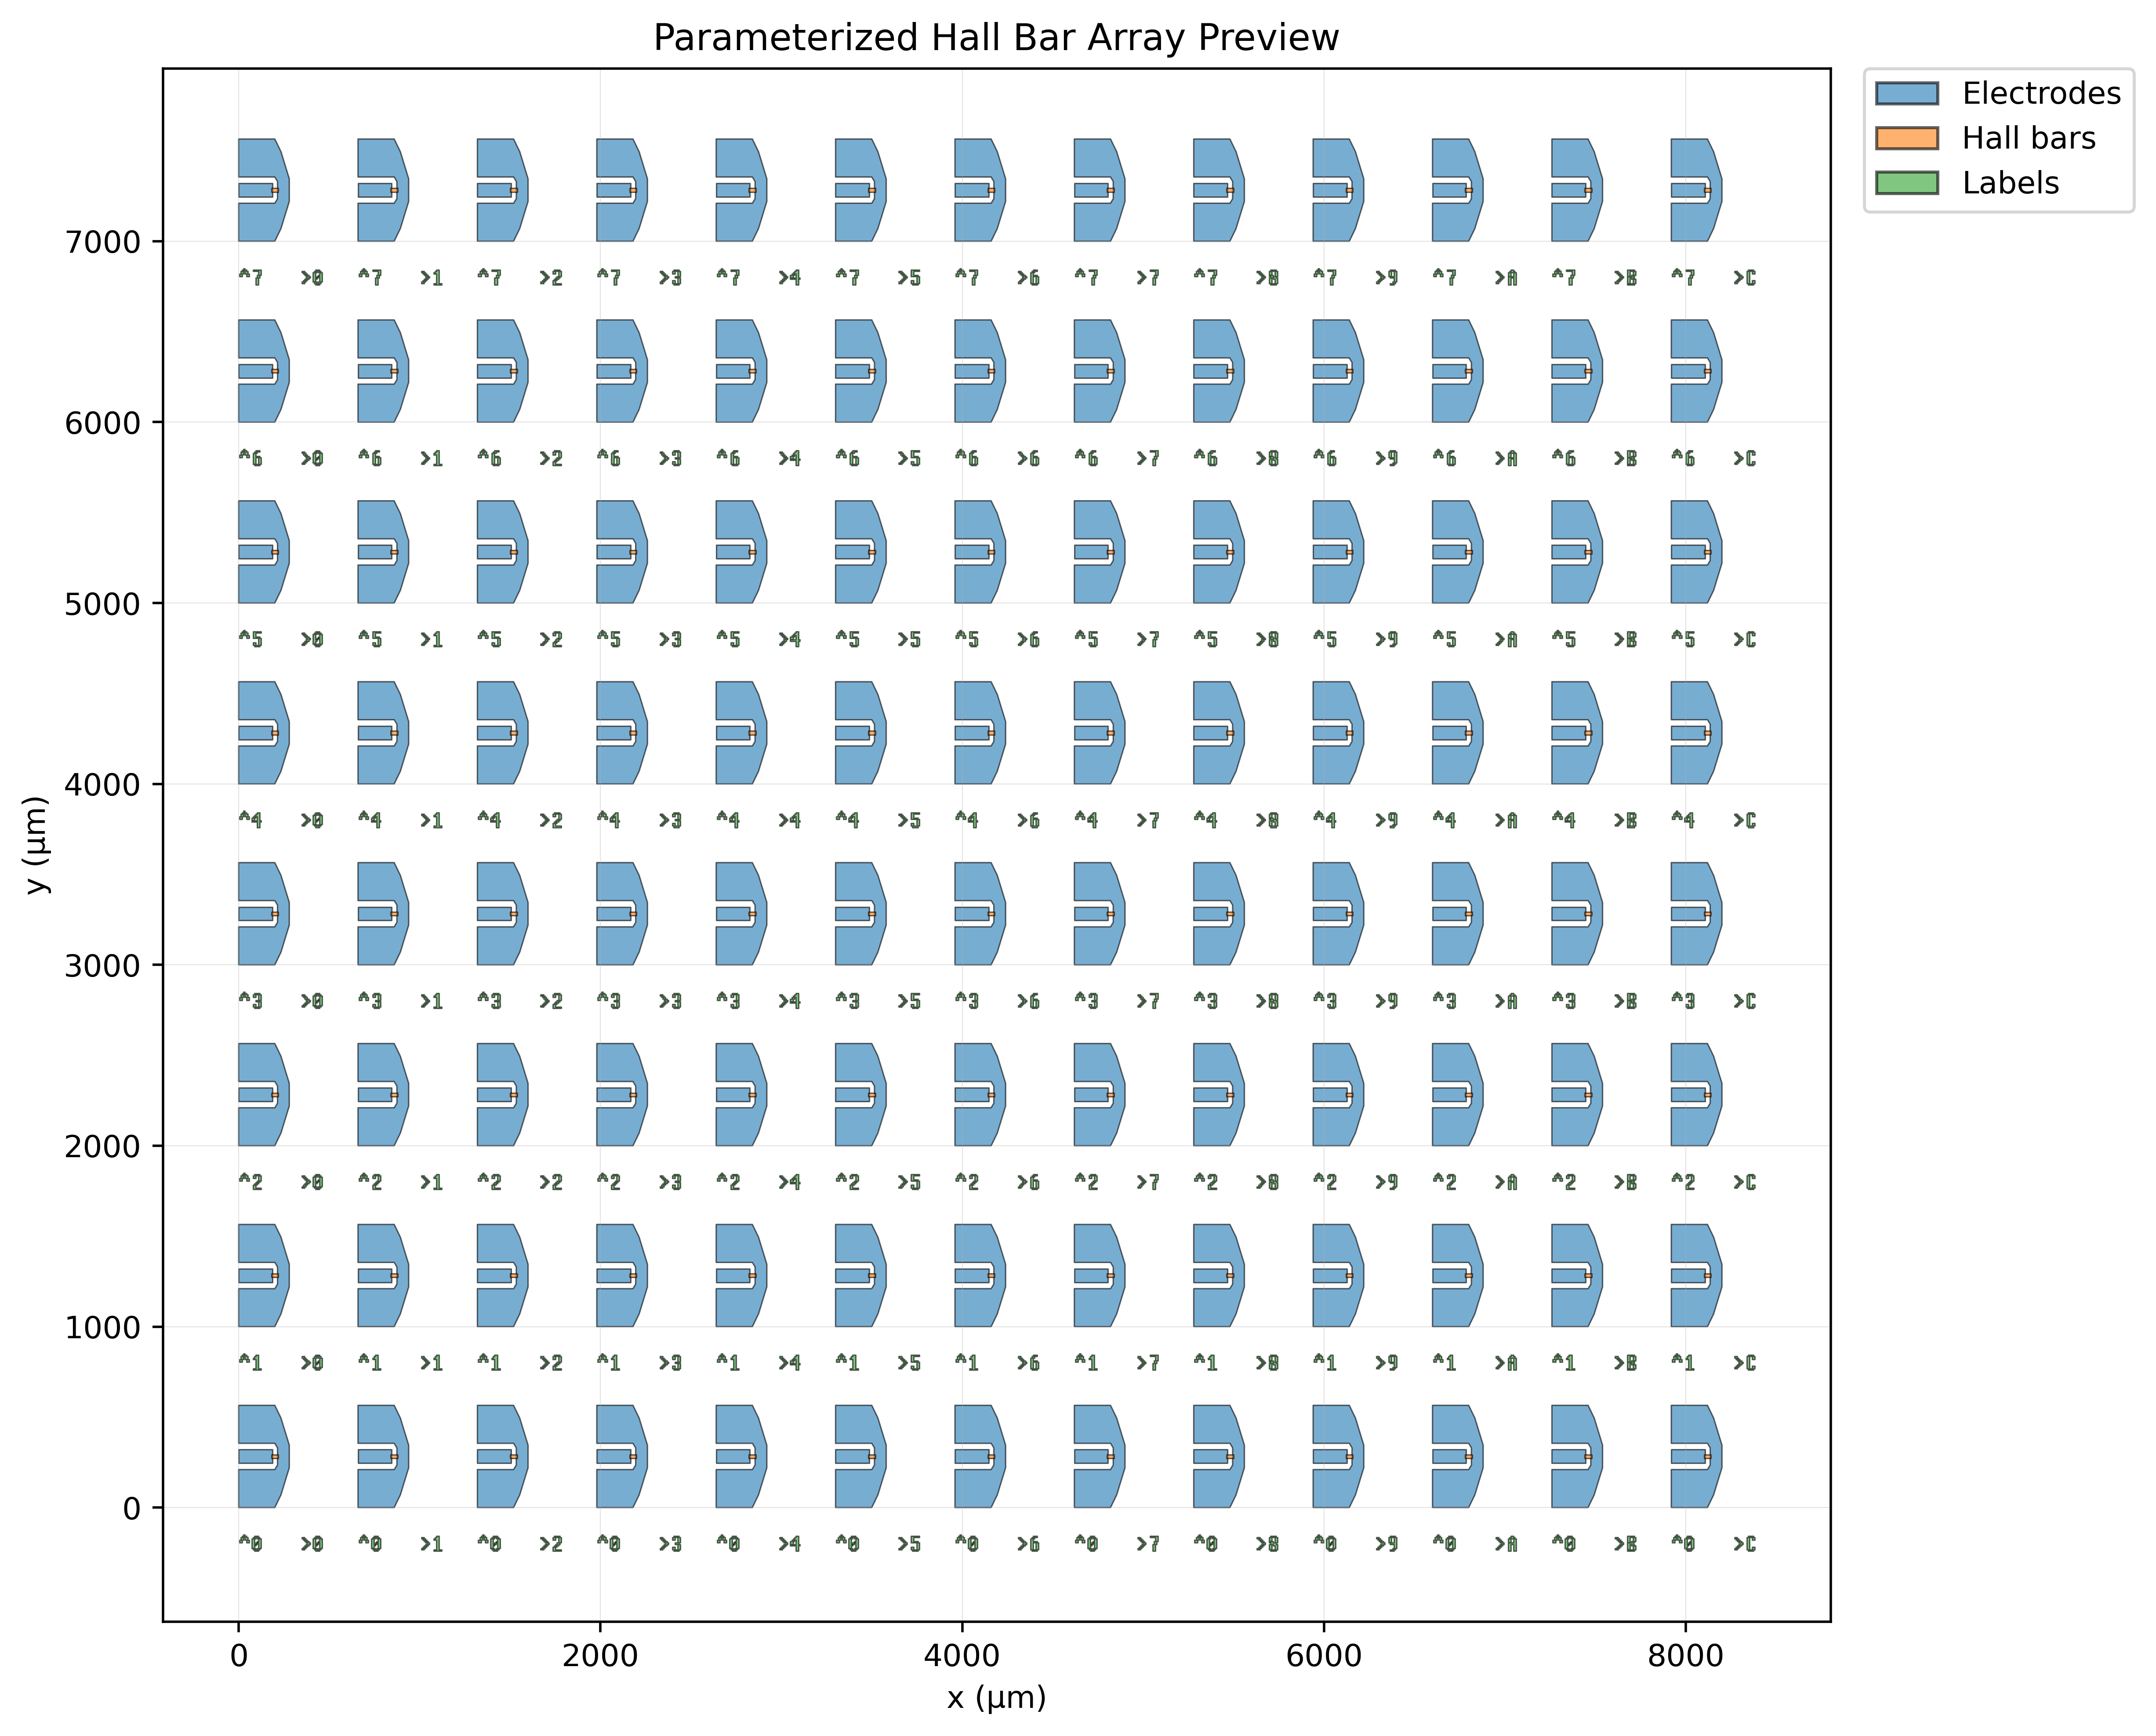

Successfully wrote the geometric layout data out to /content/ST_FMR_device_array.gds
Electrode bounding box dimensions represent 280.000 µm by 565.000 µm
Calculated array pitch spacing provides 660.000 µm by 1000.000 µm
Total array layout comprises 13 columns by 8 rows
Main Hall bar active trace width utilizes 20.000 µm


In [ ]:
"""Parameterized Spin Torque Ferromagnetic Resonance (ST-FMR) device array using PHIDL and GDSTK. """

from dataclasses import dataclass
from pathlib import Path
from typing import Final

import gdstk
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.patches import Patch

try:
    from phidl import Device
except ImportError:
    Device = None


# ---------------------------------------------------------------------------
# Control knobs
# ---------------------------------------------------------------------------

OUTPUT_DIR: Final[Path] = Path("/content")
OUTPUT_BASENAME: Final[str] = "ST_FMR_device_array"
EXPORT_FORMAT: Final[str] = "gds"  # Options include "gds" or "oas", (GDSII or OASIS, respectively).

# Set the desired array size and Hall bar width here. No rotation. Rotated devices are available in the "Spintronics-Generative-Layouts" GitHub.
# The default Hall bar trace width is set to 20 microns.
ARRAY_COLUMNS_X: Final[int] = 13
ARRAY_ROWS_Y: Final[int] = 8
MAIN_HALL_BAR_TRACE_WIDTH_UM: Final[float] = 20.0

X_EDGE_TO_EDGE_SPACING_UM: Final[float] = 380.0
Y_EDGE_TO_EDGE_SPACING_UM: Final[float] = 435.0

LABEL_TOP_OFFSET_UM: Final[float] = 150.0
LABEL_LEFT_INSET_UM: Final[float] = 5.0
LABEL_HEIGHT_UM: Final[float] = 120.0

GDS_UNIT_M: Final[float] = 1e-6
GDS_PRECISION_M: Final[float] = 1e-9

PREVIEW_DPI: Final[int] = 500
PREVIEW_ALPHA: Final[float] = 0.60
PREVIEW_LINEWIDTH: Final[float] = 0.45

plt.rcParams["figure.dpi"] = PREVIEW_DPI
plt.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
plt.rcParams["font.weight"] = "normal"

ELECTRODE_LAYER: Final[int] = 1
HALL_BAR_LAYER: Final[int] = 2
LABEL_LAYER: Final[int] = 10
DATATYPE: Final[int] = 0


# ---------------------------------------------------------------------------
# Base Geometry
# ---------------------------------------------------------------------------

BASE_ELECTRODE_POLYGONS_UM: Final[tuple[tuple[tuple[float, float], ...], ...]] = (
    (
        (0.0, 245.0), (186.0, 245.0), (186.0, 320.0), (0.0, 320.0)
    ),
    (
        (200.0, 565.0), (234.0, 495.0), (280.0, 345.0), (280.0, 220.0),
        (234.0, 70.0), (200.0, 0.0), (0.0, 0.0), (0.0, 210.0),
        (200.0, 210.0), (215.0, 235.0), (215.0, 330.0), (200.0, 355.0),
        (0.0, 355.0), (0.0, 565.0)
    ),
)


@dataclass(frozen=True)
class BaseGeometry:
    """This class acts as a container for the fundamental electrode polygon geometry."""

    electrode_polygons: list[np.ndarray]
    electrode_bbox: tuple[float, float, float, float]


@dataclass(frozen=True)
class LayerStyle:
    """This class provides plotting metadata for a Graphic Database System layer."""

    layer: int
    datatype: int
    name: str


LAYER_STYLES: Final[tuple[LayerStyle, ...]] = (
    LayerStyle(ELECTRODE_LAYER, DATATYPE, "Electrodes"),
    LayerStyle(HALL_BAR_LAYER, DATATYPE, "Hall bars"),
    LayerStyle(LABEL_LAYER, DATATYPE, "Labels"),
)


def get_electrode_geometry() -> BaseGeometry:
    """This function returns normalized electrode polygons extracted from the base coordinates."""
    polygons = [
        np.array(points, dtype=float)
        for points in BASE_ELECTRODE_POLYGONS_UM
    ]
    return BaseGeometry(polygons, (0.0, 0.0, 280.0, 565.0))


def make_hall_bar_polygons(trace_width_um: float) -> list[gdstk.Polygon]:
    """This function creates the Hall bar conductor from the reference dimensions."""
    if trace_width_um <= 0:
        raise ValueError("MAIN_HALL_BAR_TRACE_WIDTH_UM must be positive.")

    center_y = 282.5
    half_width = trace_width_um / 2.0

    rectangles = [
        gdstk.rectangle(
            (181.5, center_y - half_width),
            (219.5, center_y + half_width),
        ),
    ]

    merged = gdstk.boolean(rectangles, [], "or", precision=1e-3) or []

    for polygon in merged:
        polygon.layer = HALL_BAR_LAYER
        polygon.datatype = DATATYPE

    return merged


def alphanumeric_index(index: int) -> str:
    """This function returns alphabetical style labels for nonnegative indices."""
    if index < 0:
        raise ValueError("Index labels must be nonnegative.")

    if index < 10:
        return str(index)

    alphabet = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    index -= 10
    characters: list[str] = []

    while True:
        characters.append(alphabet[index % len(alphabet)])
        index = index // len(alphabet) - 1

        if index < 0:
            break

    return "".join(reversed(characters))


def make_device_label(row_index: int, column_index: int) -> str:
    """This function formats the cell label using bottom up rows and left to right columns."""
    row_label = alphanumeric_index(row_index)
    column_label = alphanumeric_index(column_index)
    return f"^{row_label}   >{column_label}"


def polygon_bbox(polygons: list[gdstk.Polygon]) -> tuple[float, float, float, float]:
    """This function returns the bounding box of a list of Graphic Database System polygons."""
    if not polygons:
        raise ValueError("Cannot calculate a bounding box for an empty polygon list.")

    points = np.vstack([polygon.points for polygon in polygons])
    min_x, min_y = np.min(points, axis=0)
    max_x, max_y = np.max(points, axis=0)

    return float(min_x), float(min_y), float(max_x), float(max_y)


def make_text_polygons(
    text: str,
    left_x: float,
    top_y: float,
    height_um: float,
) -> list[gdstk.Polygon]:
    """This function creates label text polygons with left edge and top edge alignment."""
    text_polygons = gdstk.text(
        text,
        height_um,
        (0.0, 0.0),
        layer=LABEL_LAYER,
        datatype=DATATYPE,
    )

    min_x, _, _, max_y = polygon_bbox(text_polygons)
    delta_x = left_x - min_x
    delta_y = top_y - max_y

    for polygon in text_polygons:
        polygon.translate(delta_x, delta_y)

    return text_polygons


def make_unit_cell(
    library: gdstk.Library,
    geometry: BaseGeometry,
    trace_width_um: float,
) -> gdstk.Cell:
    """This function creates one fixed electrode Hall bar unit cell."""
    unit_cell = library.new_cell("HALL_BAR_UNIT")

    for electrode in geometry.electrode_polygons:
        unit_cell.add(
            gdstk.Polygon(
                electrode,
                layer=ELECTRODE_LAYER,
                datatype=DATATYPE,
            )
        )

    for hall_bar in make_hall_bar_polygons(trace_width_um):
        unit_cell.add(hall_bar)

    return unit_cell


def make_hall_bar_array() -> tuple[gdstk.Library, gdstk.Cell, gdstk.Cell, dict[str, float]]:
    """This function builds the full Hall bar array and returns export metadata."""
    geometry = get_electrode_geometry()

    min_x, min_y, max_x, max_y = geometry.electrode_bbox
    electrode_width = max_x - min_x
    electrode_height = max_y - min_y

    pitch_x = electrode_width + X_EDGE_TO_EDGE_SPACING_UM
    pitch_y = electrode_height + Y_EDGE_TO_EDGE_SPACING_UM

    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    unit_cell = make_unit_cell(
        library,
        geometry,
        MAIN_HALL_BAR_TRACE_WIDTH_UM,
    )
    top_cell = library.new_cell("TOP_HALL_BAR_ARRAY")

    for row in range(ARRAY_ROWS_Y):
        for column in range(ARRAY_COLUMNS_X):
            origin = (column * pitch_x, row * pitch_y)
            top_cell.add(gdstk.Reference(unit_cell, origin=origin))

            label_text = make_device_label(row, column)
            label_left_x = origin[0] + LABEL_LEFT_INSET_UM
            label_top_y = origin[1] + min_y - LABEL_TOP_OFFSET_UM

            top_cell.add(
                *make_text_polygons(
                    label_text,
                    label_left_x,
                    label_top_y,
                    LABEL_HEIGHT_UM,
                )
            )

    metadata = {
        "electrode_width_um": electrode_width,
        "electrode_height_um": electrode_height,
        "pitch_x_um": pitch_x,
        "pitch_y_um": pitch_y,
    }

    return library, top_cell, unit_cell, metadata


def export_layout(
    library: gdstk.Library,
    basename: str,
    export_format: str,
) -> Path:
    """This function exports the layout to the designated directory."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    normalized_format = export_format.strip().upper()

    if normalized_format in {"GDS", "GDSII"}:
        output_path = OUTPUT_DIR / f"{basename}.gds"
        library.write_gds(str(output_path))
        return output_path

    if normalized_format in {"OASIS", "OAS"}:
        output_path = OUTPUT_DIR / f"{basename}.oas"
        library.write_oas(str(output_path))
        return output_path

    raise ValueError('EXPORT_FORMAT must be "GDSII" or "OASIS".')


def gdstk_cell_to_phidl_device(cell: gdstk.Cell):
    """This function mirrors a flattened GDSTK cell into a PHIDL Device for inspection."""
    if Device is None:
        return None

    device = Device(f"PHIDL_PREVIEW_{cell.name}")

    for style in LAYER_STYLES:
        polygons = cell.get_polygons(
            layer=style.layer,
            datatype=style.datatype,
        )

        for polygon in polygons:
            device.add_polygon(
                polygon.points,
                layer=(style.layer, style.datatype),
            )

    return device


def plot_layout_preview(cell: gdstk.Cell, phidl_device=None, title: str = "Layout Preview") -> None:
    """This function renders a graphical preview with the legend outside the layout axes."""
    fig, ax = plt.subplots(figsize=(12, 8))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    handles: list[Patch] = []

    if phidl_device is not None:
        polygons_by_spec = phidl_device.get_polygons(by_spec=True)
    else:
        polygons_by_spec = {
            (style.layer, style.datatype): [
                polygon.points
                for polygon in cell.get_polygons(
                    layer=style.layer,
                    datatype=style.datatype,
                )
            ]
            for style in LAYER_STYLES
        }

    for index, style in enumerate(LAYER_STYLES):
        polygons = polygons_by_spec.get((style.layer, style.datatype), [])

        if not polygons:
            continue

        facecolor = color_cycle[index % len(color_cycle)]
        collection = PolyCollection(
            polygons,
            closed=True,
            facecolors=facecolor,
            edgecolors="black",
            linewidths=PREVIEW_LINEWIDTH,
            alpha=PREVIEW_ALPHA,
            label=style.name,
        )

        ax.add_collection(collection)
        handles.append(
            Patch(
                facecolor=facecolor,
                edgecolor="black",
                alpha=PREVIEW_ALPHA,
                label=style.name,
            )
        )

    ax.autoscale_view()
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(title)
    ax.grid(True, linewidth=0.3, alpha=0.35)

    if handles:
        ax.legend(
            handles=handles,
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0.0,
            frameon=True,
        )

    fig.tight_layout(rect=(0.0, 0.0, 0.82, 1.0))
    plt.show()


# Execution and generation process
library, top_cell, unit_cell, metadata = make_hall_bar_array()
output_path = export_layout(library, OUTPUT_BASENAME, EXPORT_FORMAT)

# Isolate and plot the single unit cell close up
phidl_preview_unit = gdstk_cell_to_phidl_device(unit_cell)
plot_layout_preview(unit_cell, phidl_preview_unit, title="Isolated Hall Bar Unit Cell Close Up")

# Plot the comprehensive macroscopic array
phidl_preview_top = gdstk_cell_to_phidl_device(top_cell)
plot_layout_preview(top_cell, phidl_preview_top, title="Parameterized Hall Bar Array Preview")

print(f"Successfully wrote the geometric layout data out to {output_path}")
print(
    f"Electrode bounding box dimensions represent {metadata['electrode_width_um']:.3f} µm by "
    f"{metadata['electrode_height_um']:.3f} µm"
)
print(
    f"Calculated array pitch spacing provides {metadata['pitch_x_um']:.3f} µm by "
    f"{metadata['pitch_y_um']:.3f} µm"
)
print(f"Total array layout comprises {ARRAY_COLUMNS_X} columns by {ARRAY_ROWS_Y} rows")
print(f"Main Hall bar active trace width utilizes {MAIN_HALL_BAR_TRACE_WIDTH_UM:.3f} µm")